In [12]:
import pandas as pd

# Load dataset
df = pd.read_csv("Dry_Bean_Dataset.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nFirst 5 rows:\n")
print(df.head().to_string())

Shape: (13611, 17)

Columns:
 Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='str')

First 5 rows:

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class
0  28395    610.291       208.178117       173.888747      1.197191      0.549812       28715     190.141097  0.763923  0.988856   0.958027     0.913358      0.007332      0.003147      0.834222      0.998724  SEKER
1  28734    638.018       200.524796       182.734419      1.097356      0.411785       29172     191.272751  0.783968  0.984986   0.887034     0.953861      0.006979      0.003564      0.909851      0.998430  SEKER
2  29380    6

In [13]:
# We drop `"Class"` to prevent supervised label leakage and ensure clustering discovers structure purely from feature geometry.

X = df.drop(columns=["Class"])

print("Feature matrix shape:", X.shape)
print("\nAny missing values?\n", X.isnull().sum().sum())

Feature matrix shape: (13611, 16)

Any missing values?
 0


In [15]:
# We check feature scale because K-Means relies on Euclidean distance, which is sensitive to magnitude differences.

feature_means = X.mean()
feature_stds = X.std()

summary = pd.DataFrame({
    "Mean": feature_means,
    "Std": feature_stds
})

print(summary)

                         Mean           Std
Area             53048.284549  29324.095717
Perimeter          855.283459    214.289696
MajorAxisLength    320.141867     85.694186
MinorAxisLength    202.270714     44.970091
AspectRation         1.583242      0.246678
Eccentricity         0.750895      0.092002
ConvexArea       53768.200206  29774.915817
EquivDiameter      253.064220     59.177120
Extent               0.749733      0.049086
Solidity             0.987143      0.004660
roundness            0.873282      0.059520
Compactness          0.799864      0.061713
ShapeFactor1         0.006564      0.001128
ShapeFactor2         0.001716      0.000596
ShapeFactor3         0.643590      0.098996
ShapeFactor4         0.995063      0.004366


In [19]:
"""
feature scale caries from 0.001 to 53,000, which is a huge range. 
We scale features to equalize their influence in Euclidean distance.

"""
from sklearn.preprocessing import StandardScaler  # noqa: E402

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled mean (approx 0):\n", X_scaled.mean(axis=0)[:5])
print("\nScaled std (approx 1):\n", X_scaled.std(axis=0)[:5])

Scaled mean (approx 0):
 [ 3.34102822e-17 -4.34333668e-16  2.67282258e-16  8.68667337e-16
 -1.07748160e-15]

Scaled std (approx 1):
 [1. 1. 1. 1. 1.]


In [21]:
"""
We implement K-Means manually to understand centroid updates and inertia computation instead of relying on black-box behavior.

We begin with a single fixed (k=3) to verify correctness before elbow method.    
"""

import numpy as np  # noqa: E402

def initialize_centroids(X, k, seed=42):
    np.random.seed(seed)
    indices = np.random.choice(X.shape[0], size=k, replace=False)
    return X[indices]

def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

def compute_inertia(X, centroids, labels):
    return np.sum((X - centroids[labels]) ** 2)

def kmeans_scratch(X, k, max_iters=100, tol=1e-4, seed=42):
    centroids = initialize_centroids(X, k, seed)
    
    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        
        if np.linalg.norm(new_centroids - centroids) < tol:
            break
            
        centroids = new_centroids
    
    inertia = compute_inertia(X, centroids, labels)
    return centroids, labels, inertia

In [22]:
# Test run
centroids, labels, inertia = kmeans_scratch(X_scaled, k=3)

print("Inertia for k=3:", inertia)
print("Cluster counts:", np.bincount(labels))

Inertia for k=3: 110308.71638670213
Cluster counts: [2293 5207 6111]


In [24]:
# Elbow method to find optimal k

inertias = []
k_values = range(1, 11)

for k in k_values:
    _, _, inertia = kmeans_scratch(X_scaled, k=k)
    inertias.append(inertia)
    print(f"k={k}, Inertia={inertia}")

k=1, Inertia=217776.0
k=2, Inertia=129900.03095851379
k=3, Inertia=110308.71638670213
k=4, Inertia=85825.04141540249
k=5, Inertia=61893.64437916514
k=6, Inertia=55529.6842781514
k=7, Inertia=53273.240154442865
k=8, Inertia=46578.626241002006
k=9, Inertia=44764.977506708005
k=10, Inertia=41194.74249053406


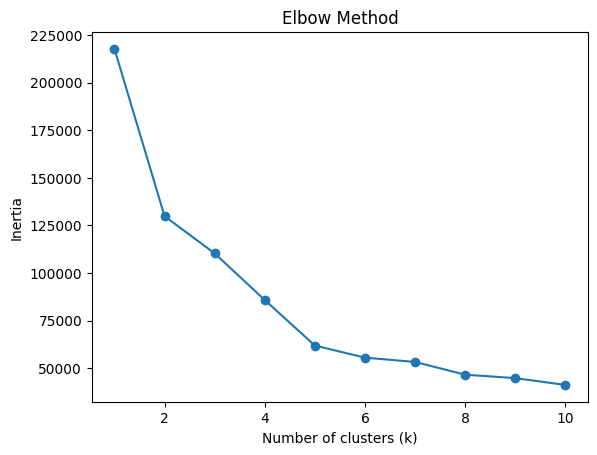

In [25]:
# visualize elbow plot
import matplotlib.pyplot as plt  # noqa: E402

plt.figure()
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [27]:
# stability test across different random seeds
# reason : If clusters are meaningful, rerunning with different seeds should not drastically change inertia or cluster structure.

seeds = [0, 21, 42, 84, 128]

print("Stability check for k=4")
for s in seeds:
    _, _, inertia = kmeans_scratch(X_scaled, k=4, seed=s)
    print(f"Seed {s}: Inertia = {inertia}")

print("\nStability check for k=5")
for s in seeds:
    _, _, inertia = kmeans_scratch(X_scaled, k=5, seed=s)
    print(f"Seed {s}: Inertia = {inertia}")

Stability check for k=4
Seed 0: Inertia = 85825.04639051814
Seed 21: Inertia = 76474.28845685768
Seed 42: Inertia = 85825.04141540249
Seed 84: Inertia = 76474.28845685768
Seed 128: Inertia = 76474.28845685768

Stability check for k=5
Seed 0: Inertia = 61893.64437916514
Seed 21: Inertia = 61893.61630329807
Seed 42: Inertia = 61893.64437916514
Seed 84: Inertia = 61893.64437916514
Seed 128: Inertia = 61893.64437916514


In [29]:
# current best candidate: k = 5
# We reduce to 2D to visually inspect separation and overlap structure.(PCA application)

from sklearn.decomposition import PCA

# Clustering in 16D (scaled space)
centroids, labels, inertia = kmeans_scratch(X_scaled, k=5, seed=42)

# PCA projection to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.55466439 0.26430973]
Total explained variance: 0.8189741181790013


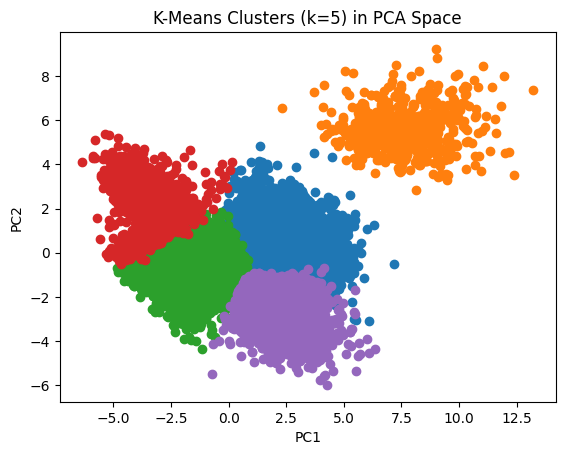

In [30]:
# visualize

import matplotlib.pyplot as plt

plt.figure()

for i in range(5):
    plt.scatter(
        X_pca[labels == i, 0],
        X_pca[labels == i, 1]
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (k=5) in PCA Space")
plt.show()

In [31]:
# To test whether clustering structure changes when magnitude dominance is present.(Sensitivity to Scaling)

# --- KMeans on UNscaled data ---
centroids_raw, labels_raw, inertia_raw = kmeans_scratch(X.values, k=5, seed=42)

print("Inertia (unscaled):", inertia_raw)
print("Cluster sizes (unscaled):", np.bincount(labels_raw))

# --- PCA on UNscaled data ---
from sklearn.decomposition import PCA  # noqa: E402

pca_raw = PCA(n_components=2)
X_pca_raw = pca_raw.fit_transform(X.values)

print("Raw PCA variance retained (2D):", pca_raw.explained_variance_ratio_.sum())

Inertia (unscaled): 1186231031954.0498
Cluster sizes (unscaled): [1791  519 2243 4651 4407]
Raw PCA variance retained (2D): 0.9999978243949357


1. Inertia exploded

Scaled inertia ≈ 61,893
Unscaled inertia ≈ 1.186 × 10¹²

Absolute value is not directly comparable, but magnitude confirms domination by large-scale features.

2. Cluster sizes changed drastically

Scaled (k=5):
Balanced-ish.

Unscaled:
[1791, 519, 2243, 4651, 4407]

One cluster extremely small (519).
Two clusters very large (~4.6k, ~4.4k).
Severe imbalance introduced.

3. PCA retained ~99.9998% variance in 2D

This tells you something crucial:

Almost all variance is concentrated in first two raw principal components.

Why?

Because large-magnitude features (Area, ConvexArea, Perimeter) dominate total variance.

Smaller shape descriptors contribute almost nothing to total variance.

Conclusion: Sensitivity to Scaling

K-Means without scaling:

Essentially clusters by size only.

Shape descriptors become irrelevant.

Geometry collapses onto area-driven axes.

This proves:

K-Means is highly sensitive to feature scaling.

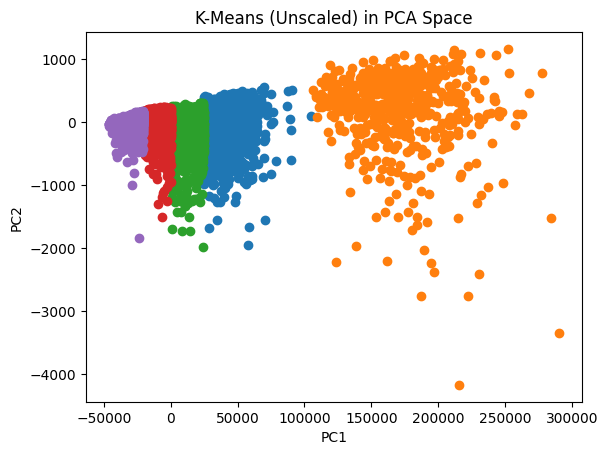

In [33]:
# Visualize Unscaled Clustering in 2D PCA
import matplotlib.pyplot as plt

plt.figure()

for i in range(5):
    plt.scatter(
        X_pca_raw[labels_raw == i, 0],
        X_pca_raw[labels_raw == i, 1]
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means (Unscaled) in PCA Space")
plt.show()

K-Means is extremely sensitive to feature scaling.

In [35]:
# To inspect whether 3D reveals separations hidden in 2D.

from sklearn.decomposition import PCA
import plotly.express as px
import pandas as pd

# 3D PCA on scaled data
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

df_3d = pd.DataFrame(X_pca3, columns=['PC1','PC2','PC3'])
df_3d['Cluster'] = labels.astype(str)

fig = px.scatter_3d(df_3d, x='PC1', y='PC2', z='PC3',
                    color='Cluster',
                    title='K-Means (k=5) - 3D PCA')

fig.show()

1. central overlapping still persist
2. hence checkingout k = 6 now

In [40]:
# To check whether adding one more cluster gives stable and meaningful structural improvement.

# Stability test for k = 6
seeds = [0, 21, 42, 84, 128]

print("Stability check for k=6")
for s in seeds:
    _, _, inertia = kmeans_scratch(X_scaled, k=6, seed=s)
    print(f"Seed {s}: Inertia = {inertia}")
    
centroids6, labels6, inertia6 = kmeans_scratch(X_scaled, k=6, seed=42)
print("\nCluster sizes (k=6):", np.bincount(labels6))    

Stability check for k=6
Seed 0: Inertia = 55529.6805831837
Seed 21: Inertia = 55529.358375871685
Seed 42: Inertia = 55529.6842781514
Seed 84: Inertia = 55529.69570206542
Seed 128: Inertia = 55529.6842781514

Cluster sizes (k=6): [2775  521 3144 2037 1947 3187]


**comparing k=5 and k=6**

*inertia redustion*

k=5 → 61,893
k=6 → 55,529

Reduction ≈ 6,364

Earlier reductions:
4 → 5 was ≈ 23,931

k=5                   | k=6
Stable                | Also stable
Moderate separation   | Slightly lower inertia
Some overlap          | More fragmentation

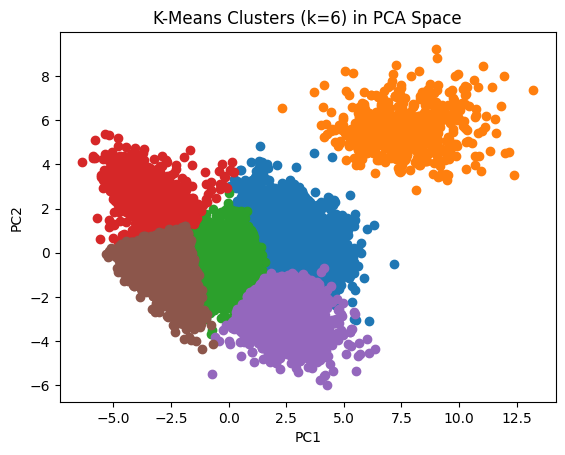

In [42]:
# Project k=6 into PCA 2D and 3D to inspect geometry.

# 2D visualization for k=6
plt.figure()

for i in range(6):
    plt.scatter(
        X_pca[labels6 == i, 0],
        X_pca[labels6 == i, 1]
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (k=6) in PCA Space")
plt.show()

this feels artificial
starting of overfitting

In [45]:
# Do these clusters represent different bean morphology profiles?
# Cluster interpretability means checking whether each cluster’s centroid shows a distinct geometric feature pattern that represents a meaningful bean morphology.

# Convert centroids back to original scale for interpretation
centroids_original = scaler.inverse_transform(centroids)

centroid_df = pd.DataFrame(
    centroids_original,
    columns=X.columns
)

print(centroid_df)

            Area    Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  Eccentricity     ConvexArea  EquivDiameter    Extent  Solidity  roundness  Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4
0   72831.966577  1051.271135       391.827409       237.658063      1.652078      0.789712   74022.881161     303.745399  0.755378  0.983826   0.825612     0.777191      0.005428      0.001230      0.605181      0.992574
1  173599.226488  1586.206916       593.424226       374.449677      1.585917      0.770660  175929.268714     469.110236  0.776612  0.986898   0.864400     0.792523      0.003441      0.000844      0.629035      0.991838
2   37592.955430   722.106717       269.326300       176.697984      1.524109      0.751076   38037.296619     217.665238  0.752143  0.988258   0.898185     0.809580      0.007302      0.001945      0.655968      0.996431
3   38649.834470   714.869991       246.785708       198.779011      1.243403      0.585672   39030.356980     2

## Scratch vs. sklearn


In [46]:
from sklearn.cluster import KMeans

kmeans_sklearn = KMeans(
    n_clusters=5,
    n_init=10,
    random_state=42
)

kmeans_sklearn.fit(X_scaled)

labels_sklearn = kmeans_sklearn.labels_
centroids_sklearn = kmeans_sklearn.cluster_centers_
inertia_sklearn = kmeans_sklearn.inertia_

print("Sklearn Inertia:", inertia_sklearn)
print("Cluster sizes:", np.bincount(labels_sklearn))

Sklearn Inertia: 61893.64437916517
Cluster sizes: [ 521 2962 2199 2073 5856]


cratch implementation is mathematically correct.

In [52]:
# Compare Centroid Geometry
# To ensure both algorithms found the same geometric partitions

from scipy.spatial.distance import cdist

# Distance matrix between scratch and sklearn centroids
distance_matrix = cdist(centroids, centroids_sklearn)

print(distance_matrix)

[[7.56213783e+00 4.48482352e-15 6.32917864e+00 3.49822077e+00
  4.42964191e+00]
 [1.55450680e-15 7.56213783e+00 1.18435763e+01 1.00993345e+01
  1.13169736e+01]
 [1.13169736e+01 4.42964191e+00 3.46436819e+00 4.67165477e+00
  3.50373437e-15]
 [1.18435763e+01 6.32917864e+00 3.34186812e-15 7.78047577e+00
  3.46436819e+00]
 [1.00993345e+01 3.49822077e+00 7.78047577e+00 5.91238196e-15
  4.67165477e+00]]


In [53]:
# Centroid Distance Analysis (Inter-cluster Distances)

# Pairwise centroid distances (scratch centroids)
centroid_distances = cdist(centroids, centroids)

print(np.round(centroid_distances, 3))

[[ 0.     7.562  4.43   6.329  3.498]
 [ 7.562  0.    11.317 11.844 10.099]
 [ 4.43  11.317  0.     3.464  4.672]
 [ 6.329 11.844  3.464  0.     7.78 ]
 [ 3.498 10.099  4.672  7.78   0.   ]]


# Are clusters stable across seeds?

Yes for k=5 and k=6.
No for k=4.

# Are they sensitive to scaling?

Extremely.
Unscaled version collapses structure into size-dominant slicing.

# clustering and classification

In [63]:
# Keep true labels separately (DO NOT use in clustering)
y_true = df["Class"].values

print("Unique classes:", len(set(y_true)))

Unique classes: 7


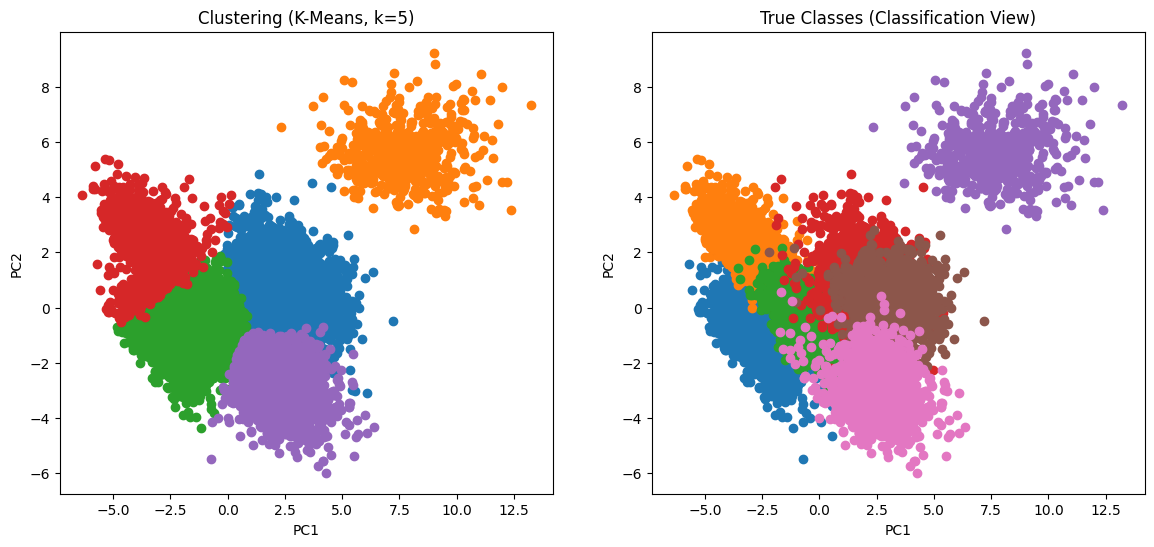

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# --- Unsupervised Clustering ---
plt.subplot(1,2,1)
for i in range(5):
    plt.scatter(
        X_pca[labels == i, 0],
        X_pca[labels == i, 1]
    )
plt.title("Clustering (K-Means, k=5)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# --- True Classification Labels ---
plt.subplot(1,2,2)
for bean in set(y_true):
    plt.scatter(
        X_pca[y_true == bean, 0],
        X_pca[y_true == bean, 1]
    )
plt.title("True Classes (Classification View)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

1. Optimal Number of Clusters

Elbow method suggested k ≈ 4–5

k=4 unstable across seeds

k=5 stable and interpretable

k=6 provided marginal improvement only

Selected k = 5



2. Scaling Sensitivity

Without scaling → clustering dominated by size features

With scaling → morphology (elongation, roundness) influenced grouping

Conclusion: K-Means is highly scale-sensitive. Standardization is mandatory.

3. Cluster Quality & Stability

Stable across multiple seeds (k=5)

Clear macro-level separation

Some central overlap

Clusters are geometrically meaningful but not perfectly separable.

Clusters are interpretable and non-arbitrary

5. Clustering vs Classification

True labels = 7 classes
Clustering found = 5 structural groups